# 문제 정의
- 로지스틱 회귀 모델을 사용하여 와인 분류하는 모델 만들어보자

### **Logistic Regression**
- 출력값(y)이 0.5보다 작은 클래스는 0
- 0.5보다 큰 클래스는 1로 예측 (2진 분류)
- 
- C값 (alpha값의 역수)에 의해 규제의 강도를 설정
- 선형 방정식 기반이라, 다른 분류 모델들에 비해 학습 및 예측 속도가 빠름
- 대량의 데이터에서 잘 동작함

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score

#로지스틱 회귀 모델 클래스
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

In [4]:
wine = pd.read_csv('data/wine.csv')
wine.head()

# 컬럼은 화학성분들 및 quality(1~10, 1이 낮음), type(1레드 0화이트)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [18]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [17]:
wine['type'].value_counts()  # 정답의 비율이 3:1 정도..

type
0    4898
1    1599
Name: count, dtype: int64

In [19]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.246114
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [23]:
# 문제, 정답, 학습, 평가 데이터로 분리
y = wine.iloc[:, -1]
X = wine.iloc[:, :-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(X_train.shape) 
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4547, 12)
(1950, 12)
(4547,)
(1950,)


#### 로지스틱회귀 모델

In [32]:
LR_model = LogisticRegression(
    C=1,           # alpha의 역수, 규제 강도 설정 (높으면 규제강도 낮아짐)
    max_iter=1000,    # 학습 횟수 지정 (너무 낮게 하면 최적 w를 찾기 전에 학습이 끝날수도..)
    penalty='l2',   # 규제방식 설정('l1, l2, elasticnet')
    solver='lbfgs',   # 최적화 방식 설정
    n_jobs=-1
)

    # <solver 종류>
     # lbfgs : 무난한 성능으로 중간 크기 (5~10만개) 이하의 데이터에 적합 (l2 지원)(디폴트)
     # liblinear : 작은 데이터셋(5만개 이하)에 적합 (l1, l2 지원)
     # saga : 대용량 데이터셋에 적합하고 빠름 (모든 규제방식 지원)
     # 데이터 개수 말고, 컬럼 개수도 고려해야 함 (테스트 필요)

In [33]:
LR_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
LR_model.score(X_train, y_train)

0.9835056080932483

In [35]:
LR_model.score(X_test, y_test)

0.9887179487179487

### 교차검증을 통해 최적의 C값 찾고 시각화하기

In [36]:
c_list = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_acc = []

for i in tqdm(c_list) : 
    LR_model = LogisticRegression(
        C=i,
        max_iter=2000
    )

    train_result = cross_val_score(LR_model, X_train, y_train, cv=10)
    train_result_mean = train_result.mean()
    train_acc.append(train_result_mean)

100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:44<00:00,  6.38s/it]


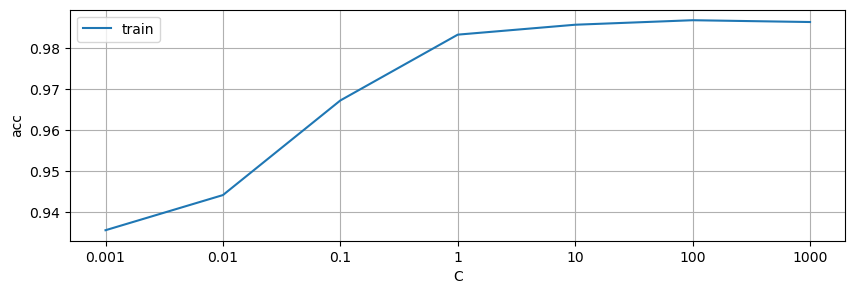

In [42]:
plt.figure(figsize=(10,3))
plt.plot(train_acc, label='train')
plt.xlabel('C')
plt.ylabel('acc')
plt.xticks(np.arange(len(c_list)),  c_list)
plt.legend()
plt.grid()
plt.show()

### 그래디언트 부스팅과 비교
- 학습 속도 비교

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

In [52]:
gbc_model = GradientBoostingClassifier(n_estimators=1000)

In [53]:
gbc_model.fit(X_train, y_train)
gbc_model.score(X_train, y_train)

0.9997800747745766

In [54]:
gbc_model.score(X_test, y_test)

0.9984615384615385

In [59]:
n_list = [100, 200, 300, 400, 500, 600, 700]
train_acc = []

for i in tqdm(n_list) : 
    gbc_model = GradientBoostingClassifier(n_estimators=i)

    train_result = cross_val_score(gbc_model, X_train, y_train, cv=10)
    train_result_mean = train_result.mean()
    train_acc.append(train_result_mean)

100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [05:48<00:00, 49.75s/it]


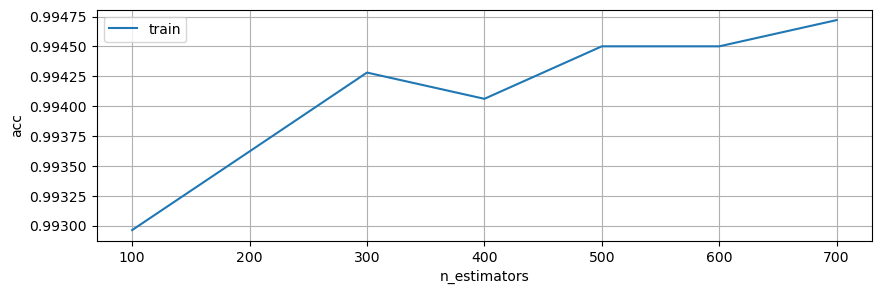

In [60]:
plt.figure(figsize=(10,3))
plt.plot(train_acc, label='train')
plt.xlabel('n_estimators')
plt.ylabel('acc')
plt.xticks(np.arange(len(n_list)),  n_list)
plt.legend()
plt.grid()
plt.show()

### 그리드서치 사용해서 로지스틱회귀모델의 C와 max_iter값 찾아보자

In [55]:
from sklearn.model_selection import GridSearchCV

In [58]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
             'max_iter': range(0, 10001, 1000)
             }
grid_LR = GridSearchCV(LogisticRegression(),
                      param_grid,
                      cv=5,
                      verbose=1
                      )
grid_LR.fit(X_train, y_train)

Fitting 5 folds for each of 77 candidates, totalling 385 fits


C:\Users\agnes\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=0).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\agnes\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=0).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to t

,estimator,LogisticRegression()
,param_grid,"{'C': [0.001, 0.01, ...], 'max_iter': range(0, 10001, 1000)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [61]:
grid_LR.score(X_test, y_test)

0.9923076923076923

In [63]:
print("최적 매개변수:", grid_LR.best_params_)
print("최고 교차 검증 점수:", grid_LR.best_score_)

최적 매개변수: {'C': 1000, 'max_iter': 1000}
최적 매개변수: 0.9874647904350875
